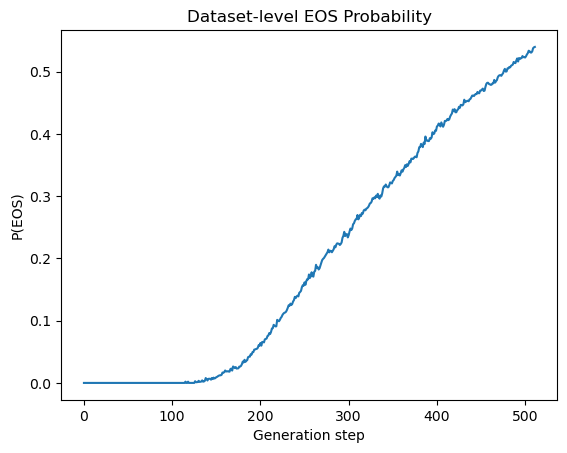

In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt

results = [json.loads(line) for line in open("predictions.jsonl")]

eos_profiles = [
    r['eos_prob_profile']
    for r in results
    if r['eos_prob_profile'] is not None
]

max_len = max(len(p) for p in eos_profiles)
eos_matrix = np.full((len(eos_profiles), max_len), np.nan)

for i, p in enumerate(eos_profiles):
    eos_matrix[i, :len(p)] = p

mean_eos = np.nanmean(eos_matrix, axis=0)

plt.plot(mean_eos)
plt.xlabel("Generation step")
plt.ylabel("P(EOS)")
plt.title("Dataset-level EOS Probability")
plt.show()


In [26]:
def eos_spike_step(profile, tau=0.5):
    for i, p in enumerate(profile):
        if p > tau:
            return i
    return None

In [27]:
import json

results = [json.loads(line) for line in open("predictions.jsonl")]

spike_steps = []

for r in results:
    profile = r.get('eos_prob_profile')
    if profile is not None:
        t = eos_spike_step(profile, tau=0.5)
        spike_steps.append(t)


In [28]:
valid_spikes = [t for t in spike_steps if t is not None]

mean_spike = sum(valid_spikes) / len(valid_spikes)
median_spike = sorted(valid_spikes)[len(valid_spikes)//2]

print("Mean EOS spike step:", mean_spike)
print("Median EOS spike step:", median_spike)
print("Fraction with no EOS spike:",
      spike_steps.count(None) / len(spike_steps))


Mean EOS spike step: 307.3890577507599
Median EOS spike step: 305
Fraction with no EOS spike: 0.342


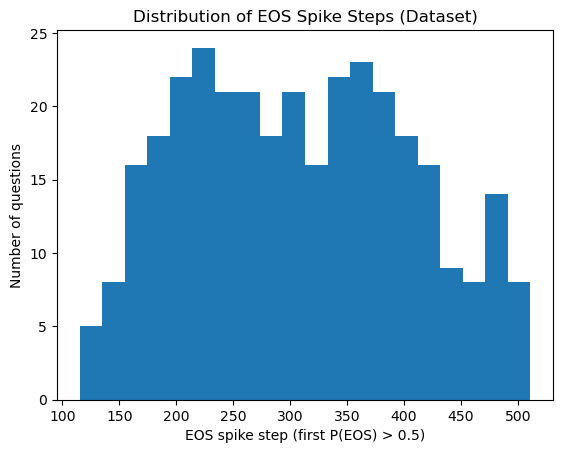

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(valid_spikes, bins=20)
plt.xlabel("EOS spike step (first P(EOS) > 0.5)")
plt.ylabel("Number of questions")
plt.title("Distribution of EOS Spike Steps (Dataset)")
plt.show()


In [30]:
correct_spikes = []
wrong_spikes = []

for r in results:
    profile = r.get('eos_prob_profile')
    if profile is None:
        continue
    t = eos_spike_step(profile)
    if t is None:
        continue
    if r['accuracy']:
        correct_spikes.append(t)
    else:
        wrong_spikes.append(t)


In [33]:
def safe_mean(x):
    return sum(x) / len(x) if len(x) > 0 else None

avg_correct = safe_mean(correct_spikes)
avg_incorrect = safe_mean(wrong_spikes)

print(f"Average EOS spike step (correct):   {avg_correct}")
print(f"Average EOS spike step (incorrect): {avg_incorrect}")

print(f"#correct samples used:   {len(correct_spikes)}")
print(f"#incorrect samples used: {len(wrong_spikes)}")


Average EOS spike step (correct):   288.6057692307692
Average EOS spike step (incorrect): 339.6776859504132
#correct samples used:   208
#incorrect samples used: 121


In [34]:
import scipy
from scipy.stats import ttest_ind

t, p = ttest_ind(correct_spikes, wrong_spikes, equal_var=False)
print("p-value:", p)


p-value: 4.7239622902727414e-06


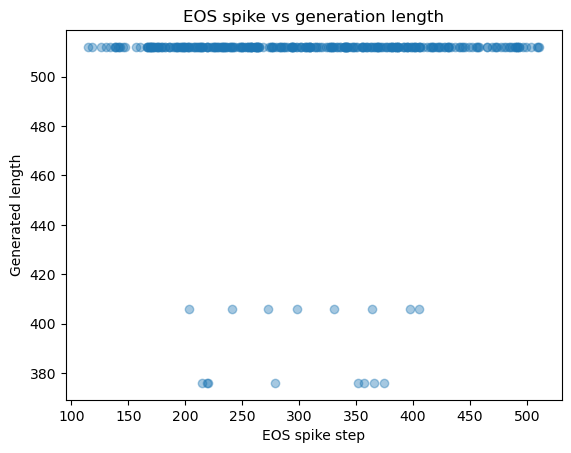

In [35]:
import matplotlib.pyplot as plt

x = []
y = []

for r in results:
    profile = r.get('eos_prob_profile')
    if profile is None:
        continue
    t = eos_spike_step(profile)
    if t is None:
        continue
    x.append(t)
    y.append(r['generated_length'])

plt.scatter(x, y, alpha=0.4)
plt.xlabel("EOS spike step")
plt.ylabel("Generated length")
plt.title("EOS spike vs generation length")
plt.show()


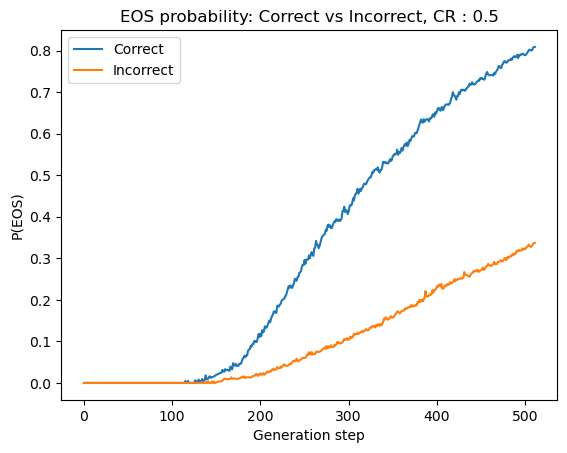

In [37]:
def mean_eos(results_subset):
    profiles = [r['eos_prob_profile'] for r in results_subset if r.get('eos_prob_profile')]
    max_len = max(len(p) for p in profiles)
    mat = np.full((len(profiles), max_len), np.nan)
    for i, p in enumerate(profiles):
        mat[i, :len(p)] = p
    return np.nanmean(mat, axis=0)

correct = [r for r in results if r['accuracy']]
incorrect = [r for r in results if not r['accuracy']]

plt.plot(mean_eos(correct), label="Correct")
plt.plot(mean_eos(incorrect), label="Incorrect")
plt.xlabel("Generation step")
plt.ylabel("P(EOS)")
plt.legend()
plt.title("EOS probability: Correct vs Incorrect, CR : 0.5")
plt.show()


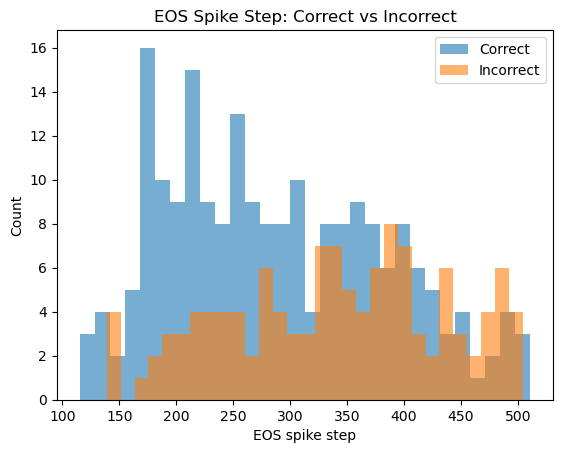

In [31]:
plt.figure()
plt.hist(correct_spikes, bins=30, alpha=0.6, label="Correct")
plt.hist(wrong_spikes, bins=30, alpha=0.6, label="Incorrect")
plt.xlabel("EOS spike step")
plt.ylabel("Count")
plt.title("EOS Spike Step: Correct vs Incorrect")
plt.legend()
plt.show()
